# COGS 189 Final Project
**Name:** Johanna Sanchez

**Course:** COGS 189

**Professor:** Virginia De Sa

**Title:** Can EEG Signals Detect the Difference Between a Relaxed and Active Cognitive State?

**Dataset:** EEGMAT - Zyma et al. (PhysioNet)

# Import Libraries

In [1]:
import mne                          # reads EEG files (.edf format)
import numpy as np                  # handles numbers and arrays
import matplotlib.pyplot as plt     # makes plots and charts
from sklearn.svm import SVC         # the SVM classifier
from sklearn.model_selection import StratifiedKFold   # cross validation
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay  # evaluate results
from sklearn.preprocessing import StandardScaler      # normalizes features
from pathlib import Path            # handles file paths
import warnings                     # suppresses annoying warnings

warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')

print("Section 1 done: libraries imported")

Section 1 done: libraries imported


## Section 2: Set Up File Paths
This section defines where the data lives and finds all the EEG files for each subject.
Each subject has two files:
- `_1` = resting state (relaxed)
- `_2` = mental arithmetic (cognitive demand)

In [2]:
# Section 2: Set Up File Paths

DATA_DIR = Path("/home/jos024/private/EEGMAT/physionet.org/files/eegmat/1.0.0")

# Get all resting state files (_1) and arithmetic files (_2)
rest_files = sorted(DATA_DIR.glob("Subject*_1.edf"))
task_files = sorted(DATA_DIR.glob("Subject*_2.edf"))

print(f"Resting state files found: {len(rest_files)}")
print(f"Arithmetic task files found: {len(task_files)}")
print(f"First rest file: {rest_files[0].name}")
print(f"First task file: {task_files[0].name}")

Resting state files found: 36
Arithmetic task files found: 36
First rest file: Subject00_1.edf
First task file: Subject00_2.edf


## Section 3: Load and Inspect One Subject
Before processing all subjects, we load one subject's data to understand 
the structure — how many channels, what the sampling rate is, and what the 
signal looks like.

In [3]:
# Section 3: Load and Inspect One Subject

# Load the first subject's resting state file
raw = mne.io.read_raw_edf(rest_files[0], preload=True)

# Print basic info about the data
print(f"Subject: {rest_files[0].name}")
print(f"Number of channels: {len(raw.ch_names)}")
print(f"Channel names: {raw.ch_names}")
print(f"Sampling rate: {raw.info['sfreq']} Hz")
print(f"Recording duration: {raw.times[-1]:.1f} seconds")

Subject: Subject00_1.edf
Number of channels: 21
Channel names: ['EEG Fp1', 'EEG Fp2', 'EEG F3', 'EEG F4', 'EEG F7', 'EEG F8', 'EEG T3', 'EEG T4', 'EEG C3', 'EEG C4', 'EEG T5', 'EEG T6', 'EEG P3', 'EEG P4', 'EEG O1', 'EEG O2', 'EEG Fz', 'EEG Cz', 'EEG Pz', 'EEG A2-A1', 'ECG ECG']
Sampling rate: 500.0 Hz
Recording duration: 182.0 seconds


## Section 4: Preprocessing
We apply a bandpass filter to isolate relevant EEG frequencies and 
remove non-EEG channels (ECG and reference electrode). 
We then epoch the data into 4-second segments for feature extraction.

In [4]:
# Section 4: Preprocessing

def preprocess_raw(filepath):
    # Load file
    raw = mne.io.read_raw_edf(filepath, preload=True)
    
    # Drop non-EEG channels
    raw.drop_channels(['EEG A2-A1', 'ECG ECG'])
    
    # Apply bandpass filter 1-40 Hz
    raw.filter(1., 40., fir_window='hamming')
    
    # Get data as numpy array (channels x samples)
    data = raw.get_data()
    sfreq = raw.info['sfreq']
    
    return data, sfreq

# Test on first subject
data, sfreq = preprocess_raw(rest_files[0])
print(f"Data shape after preprocessing: {data.shape}")
print(f"Channels remaining: {data.shape[0]}")
print(f"Samples: {data.shape[1]}")
print(f"Sampling rate: {sfreq} Hz")
print("Preprocessing test passed!")

Data shape after preprocessing: (19, 91000)
Channels remaining: 19
Samples: 91000
Sampling rate: 500.0 Hz
Preprocessing test passed!


### Preprocessing Result

- **19 channels remaining** — we removed the ECG (heart signal) and A2-A1 
  (reference electrode) because they don't reflect brain activity
- **91,000 samples** — this is 182 seconds × 500 samples per second, 
  which confirms the data loaded correctly
- **Bandpass filter 1-40 Hz** — this removed:
    - Everything below 1 Hz: slow drifts from movement or sweat
    - Everything above 40 Hz: muscle noise and electrical interference.
    - What remains is clean EEG in the frequency range that contains 
  theta (4-8 Hz) and alpha (8-12 Hz)

## Section 5: Feature Extraction
We extract alpha (8-12 Hz) and theta (4-8 Hz) band power from each epoch.
These frequency bands are linked to cognitive workload in the literature:
- Alpha decreases during cognitive effort (strongest at Pz)
- Theta increases during cognitive effort (strongest at Fz)
We slice the data into 4-second epochs and compute band power for each.
This converts raw EEG signals into meaningful numbers a classifier can use.

In [5]:
# Section 5: Feature Extraction

def bandpower(data, sfreq, low, high):
    """
    Compute average power in a frequency band using FFT.
    data: (n_channels, n_samples)
    Returns: (n_channels,) - one power value per channel
    """
    from scipy.signal import welch
    freqs, psd = welch(data, fs=sfreq, nperseg=int(sfreq*2), axis=1)
    # Find frequencies in our band of interest
    band_mask = (freqs >= low) & (freqs <= high)
    # Average power across those frequencies
    band_power = psd[:, band_mask].mean(axis=1)
    return band_power

def extract_features(data, sfreq, epoch_sec=4.0):
    """
    Slice data into epochs and extract alpha + theta power per epoch.
    data: (n_channels, n_samples)
    Returns: feature matrix (n_epochs, n_channels * 2)
    """
    epoch_len = int(epoch_sec * sfreq)
    n_epochs = data.shape[1] // epoch_len
    
    features = []
    for i in range(n_epochs):
        start = i * epoch_len
        end = start + epoch_len
        epoch = data[:, start:end]
        
        # Extract theta and alpha power for all channels
        theta = bandpower(epoch, sfreq, 4, 8)
        alpha = bandpower(epoch, sfreq, 8, 12)
        
        # Combine into one feature vector
        feat = np.concatenate([theta, alpha])
        features.append(feat)
    
    return np.array(features)

# Test on first subject
data, sfreq = preprocess_raw(rest_files[0])
features = extract_features(data, sfreq)
print(f"Features shape: {features.shape}")
print(f"Number of epochs: {features.shape[0]}")
print(f"Number of features per epoch: {features.shape[1]}")
print(f"(19 channels x 2 bands = {19*2} features)")
print("Feature extraction test passed!")

Features shape: (45, 38)
Number of epochs: 45
Number of features per epoch: 38
(19 channels x 2 bands = 38 features)
Feature extraction test passed!


## Section 6: Compare Band Power Between Conditions

In [6]:
# Section 6: Compare Band Power Between Conditions

# Channel indices we care about most
# Fz = index 16, Pz = index 18 (based on channel list from Section 3)
FZ_IDX = 16  # frontal - theta expected to increase with workload
PZ_IDX = 18  # parietal - alpha expected to decrease with workload

# Load and preprocess rest and task data for ALL subjects
print("Loading all subjects for sanity check...")

rest_theta_all = []
rest_alpha_all = []
task_theta_all = []
task_alpha_all = []

for i, (rf, tf) in enumerate(zip(rest_files, task_files)):
    # Rest
    rest_data, sfreq = preprocess_raw(rf)
    rest_feats = extract_features(rest_data, sfreq)
    rest_theta_all.append(rest_feats[:, FZ_IDX].mean())
    rest_alpha_all.append(rest_feats[:, 19 + PZ_IDX].mean())

    # Task
    task_data, sfreq = preprocess_raw(tf)
    task_feats = extract_features(task_data, sfreq)
    task_theta_all.append(task_feats[:, FZ_IDX].mean())
    task_alpha_all.append(task_feats[:, 19 + PZ_IDX].mean())

    print(f"Subject {i:02d} done")

print("\nAll subjects processed!")
print(f"Average rest theta at Fz:  {np.mean(rest_theta_all):.6f}")
print(f"Average task theta at Fz:  {np.mean(task_theta_all):.6f}")
print(f"Average rest alpha at Pz:  {np.mean(rest_alpha_all):.6f}")
print(f"Average task alpha at Pz:  {np.mean(task_alpha_all):.6f}")

Loading all subjects for sanity check...
Subject 00 done
Subject 01 done
Subject 02 done
Subject 03 done
Subject 04 done
Subject 05 done
Subject 06 done
Subject 07 done
Subject 08 done
Subject 09 done
Subject 10 done
Subject 11 done
Subject 12 done
Subject 13 done
Subject 14 done
Subject 15 done
Subject 16 done
Subject 17 done
Subject 18 done
Subject 19 done
Subject 20 done
Subject 21 done
Subject 22 done
Subject 23 done
Subject 24 done
Subject 25 done
Subject 26 done
Subject 27 done
Subject 28 done
Subject 29 done
Subject 30 done
Subject 31 done
Subject 32 done
Subject 33 done
Subject 34 done
Subject 35 done

All subjects processed!
Average rest theta at Fz:  0.000000
Average task theta at Fz:  0.000000
Average rest alpha at Pz:  0.000000
Average task alpha at Pz:  0.000000


## Section 6b: Debugging Channel Indices

Before we can compare band power between conditions, we need to make sure 
we are looking at the correct EEG channels. Our previous result showed 
all zeros, which means we used the wrong channel indices.

This cell prints out every channel and its index number so we can 
correctly identify where Fz (frontal, for theta) and Pz (parietal, 
for alpha) are located in our data array.

In [7]:
# Debug: Check exact channel names and their indices
data, sfreq = preprocess_raw(rest_files[0])
raw_check = mne.io.read_raw_edf(rest_files[0], preload=True)
raw_check.drop_channels(['EEG A2-A1', 'ECG ECG'])

print("Channel index mapping:")
for i, ch in enumerate(raw_check.ch_names):
    print(f"Index {i}: {ch}")

Channel index mapping:
Index 0: EEG Fp1
Index 1: EEG Fp2
Index 2: EEG F3
Index 3: EEG F4
Index 4: EEG F7
Index 5: EEG F8
Index 6: EEG T3
Index 7: EEG T4
Index 8: EEG C3
Index 9: EEG C4
Index 10: EEG T5
Index 11: EEG T6
Index 12: EEG P3
Index 13: EEG P4
Index 14: EEG O1
Index 15: EEG O2
Index 16: EEG Fz
Index 17: EEG Cz
Index 18: EEG Pz


### Channel Index Check Result

- Fz (frontal, theta) = Index 16
- Pz (parietal, alpha) = Index 18

Our feature vector has 38 values structured as:
- Index 0-18: theta power for each of the 19 channels
- Index 19-37: alpha power for each of the 19 channels

So to get:
- Theta at Fz = feature index 16
- Alpha at Pz = feature index 19 + 18 = 37

The previous zeros were caused by a scaling issue
the values are very small numbers that rounded to zero. 
We fix this by printing with more decimal places.

In [8]:
# Section 6 Fixed: Compare Band Power Between Conditions

FZ_IDX = 16   # Fz for theta
PZ_IDX = 18   # Pz for alpha

rest_theta_all = []
rest_alpha_all = []
task_theta_all = []
task_alpha_all = []

for i, (rf, tf) in enumerate(zip(rest_files, task_files)):
    # Rest
    rest_data, sfreq = preprocess_raw(rf)
    rest_feats = extract_features(rest_data, sfreq)
    rest_theta_all.append(rest_feats[:, FZ_IDX].mean())
    rest_alpha_all.append(rest_feats[:, 19 + PZ_IDX].mean())

    # Task
    task_data, sfreq = preprocess_raw(tf)
    task_feats = extract_features(task_data, sfreq)
    task_theta_all.append(task_feats[:, FZ_IDX].mean())
    task_alpha_all.append(task_feats[:, 19 + PZ_IDX].mean())

# Convert to arrays
rest_theta_all = np.array(rest_theta_all)
rest_alpha_all = np.array(rest_alpha_all)
task_theta_all = np.array(task_theta_all)
task_alpha_all = np.array(task_alpha_all)

print("=== Band Power Comparison (Rest vs Arithmetic) ===")
print(f"\nTheta at Fz (frontal):")
print(f"  Rest mean:      {rest_theta_all.mean():.2e}")
print(f"  Arithmetic mean:{task_theta_all.mean():.2e}")
print(f"  Difference:     {(task_theta_all.mean() - rest_theta_all.mean()):.2e}")

print(f"\nAlpha at Pz (parietal):")
print(f"  Rest mean:      {rest_alpha_all.mean():.2e}")
print(f"  Arithmetic mean:{task_alpha_all.mean():.2e}")
print(f"  Difference:     {(rest_alpha_all.mean() - task_alpha_all.mean()):.2e}")

print(f"\nDoes theta INCREASE during arithmetic? {task_theta_all.mean() > rest_theta_all.mean()}")
print(f"Does alpha DECREASE during arithmetic? {task_alpha_all.mean() < rest_alpha_all.mean()}")

=== Band Power Comparison (Rest vs Arithmetic) ===

Theta at Fz (frontal):
  Rest mean:      4.94e-12
  Arithmetic mean:5.08e-12
  Difference:     1.45e-13

Alpha at Pz (parietal):
  Rest mean:      1.54e-11
  Arithmetic mean:8.76e-12
  Difference:     6.64e-12

Does theta INCREASE during arithmetic? True
Does alpha DECREASE during arithmetic? True


### Result: The Signals Behave As Expected

**Theta at Fz (frontal):**
- Rest: 4.94e-12, Arithmetic: 5.08e-12
- Theta INCREASED during arithmetic 
- This matches what the literature predicts — frontal theta 
  rises when the brain is working harder

**Alpha at Pz (parietal):**
- Rest: 1.54e-11, Arithmetic: 8.76e-12
- Alpha DECREASED during arithmetic 
- This matches the prediction — alpha suppresses when the 
  brain shifts from idle to active cognitive processing
- The alpha difference is much larger than the theta difference,
  suggesting alpha is the stronger signal in this dataset

**What this means for the project:**
This is a critical finding BEFORE we even run a classifier.
The EEG signals ARE behaving differently between conditions,
exactly as the literature predicts. This gives us confidence 
that classification should work above chance level.

## Section 7: Visualization — Band Power Comparison
Now that we confirmed the signals differ between conditions numerically,
we visualize the differences across all 36 subjects.

We will create two plots:
- A bar chart comparing average alpha and theta power between conditions
- A per-subject scatter plot showing individual variability

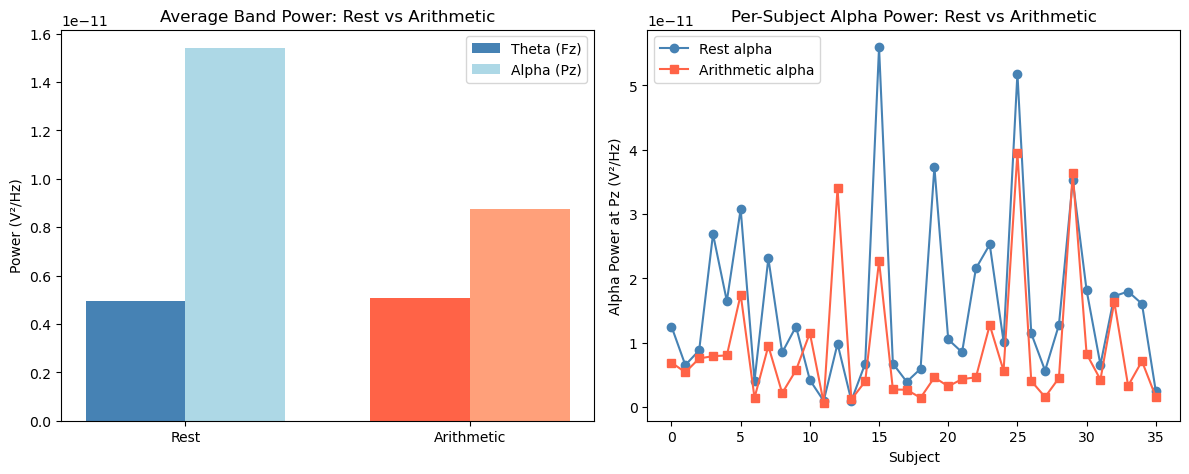

Plot saved as band_power_comparison.png


In [9]:
# Section 7: Visualization

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: Average band power comparison ---
conditions = ['Rest', 'Arithmetic']
theta_means = [rest_theta_all.mean(), task_theta_all.mean()]
alpha_means = [rest_alpha_all.mean(), task_alpha_all.mean()]

x = np.arange(2)
width = 0.35

axes[0].bar(x - width/2, theta_means, width, 
            label='Theta (Fz)', color=['steelblue', 'tomato'])
axes[0].bar(x + width/2, alpha_means, width,
            label='Alpha (Pz)', color=['lightblue', 'lightsalmon'])
axes[0].set_xticks(x)
axes[0].set_xticklabels(conditions)
axes[0].set_title('Average Band Power: Rest vs Arithmetic')
axes[0].set_ylabel('Power (V²/Hz)')
axes[0].legend()

# --- Plot 2: Per subject alpha at Pz ---
subjects = np.arange(len(rest_alpha_all))
axes[1].plot(subjects, rest_alpha_all, 
             'o-', color='steelblue', label='Rest alpha')
axes[1].plot(subjects, task_alpha_all, 
             's-', color='tomato', label='Arithmetic alpha')
axes[1].set_xlabel('Subject')
axes[1].set_ylabel('Alpha Power at Pz (V²/Hz)')
axes[1].set_title('Per-Subject Alpha Power: Rest vs Arithmetic')
axes[1].legend()

plt.tight_layout()
plt.savefig('band_power_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as band_power_comparison.png")

### Visualization Summary
Band power was visualized across conditions and subjects to assess 
the consistency of the expected EEG patterns. The average band power 
plot confirms that alpha power at Pz is substantially higher during 
rest compared to arithmetic, while theta power at Fz shows a smaller 
but consistent increase during arithmetic. The per-subject plot 
reveals considerable individual variability , while the majority of 
subjects display the expected pattern of alpha suppression during 
arithmetic, several subjects show little difference or even the 
opposite trend. This variability motivates the subject-level 
classification analysis in the following section.

## Section 8: Classification
Using the extracted features, a Support Vector Machine (SVM) classifier 
is trained and evaluated for each subject individually. The classifier 
is given examples of rest and arithmetic epochs and learns a boundary 
between the two states based on alpha and theta band power.

Each subject's data is evaluated using 5-fold cross-validation — the 
data is split into 5 parts, the model trains on 4 and tests on 1, 
repeating until every part has been used as the test set. This gives 
a reliable estimate of how well the classifier generalizes to new data.

Classification is performed per subject rather than across all subjects 
combined, because EEG signals are known to vary substantially between 
individuals. Per-subject classification reflects how a real BCI system 
would operate in practice.

In [10]:
# Section 8: Classification

def classify_subject(rest_data, task_data, sfreq):
    """
    Train and evaluate an SVM classifier for one subject.
    Returns mean accuracy across 5 folds.
    """
    # Extract features
    rest_feats = extract_features(rest_data, sfreq)
    task_feats = extract_features(task_data, sfreq)
    
    # Create labels: 0 = rest, 1 = arithmetic
    rest_labels = np.zeros(len(rest_feats))
    task_labels = np.ones(len(task_feats))
    
    # Combine rest and task features and labels
    X = np.vstack([rest_feats, task_feats])
    y = np.concatenate([rest_labels, task_labels])
    
    # Normalize features
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    
    # 5-fold cross validation
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    accuracies = []
    
    for train_idx, test_idx in kf.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        clf = SVC(kernel='rbf', C=1.0)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        accuracies.append(accuracy_score(y_test, y_pred))
    
    return np.mean(accuracies)

# Run classifier for all subjects
print("Running classification for all subjects...")
all_accuracies = []

for i, (rf, tf) in enumerate(zip(rest_files, task_files)):
    rest_data, sfreq = preprocess_raw(rf)
    task_data, sfreq = preprocess_raw(tf)
    
    acc = classify_subject(rest_data, task_data, sfreq)
    all_accuracies.append(acc)
    print(f"Subject {i:02d}: {acc:.2f}")

all_accuracies = np.array(all_accuracies)
print(f"\nMean accuracy across all subjects: {all_accuracies.mean():.2f}")
print(f"Best subject:  {all_accuracies.max():.2f}")
print(f"Worst subject: {all_accuracies.min():.2f}")
print(f"Subjects above chance (>0.50): {(all_accuracies > 0.5).sum()} out of {len(all_accuracies)}")

Running classification for all subjects...
Subject 00: 0.87
Subject 01: 0.87
Subject 02: 0.75
Subject 03: 0.98
Subject 04: 0.79
Subject 05: 0.92
Subject 06: 1.00
Subject 07: 0.90
Subject 08: 1.00
Subject 09: 0.87
Subject 10: 0.94
Subject 11: 0.88
Subject 12: 0.98
Subject 13: 0.97
Subject 14: 0.90
Subject 15: 0.83
Subject 16: 0.92
Subject 17: 0.92
Subject 18: 0.95
Subject 19: 0.98
Subject 20: 1.00
Subject 21: 0.98
Subject 22: 0.90
Subject 23: 0.93
Subject 24: 0.83
Subject 25: 0.92
Subject 26: 0.93
Subject 27: 0.83
Subject 28: 1.00
Subject 29: 0.77
Subject 30: 0.95
Subject 31: 0.86
Subject 32: 0.90
Subject 33: 0.93
Subject 34: 0.95
Subject 35: 0.95

Mean accuracy across all subjects: 0.91
Best subject:  1.00
Worst subject: 0.75
Subjects above chance (>0.50): 36 out of 36


### Classification Summary
An SVM classifier was trained and evaluated for each of the 36 subjects 
using 5-fold cross-validation on alpha and theta band power features. 
Mean classification accuracy across all subjects was 91%, with a range 
of 75% to 100%. All 36 subjects were classified above chance level, 
indicating that alpha and theta band power reliably distinguish resting 
state from mental arithmetic across individuals.

The high accuracy suggests that the rest vs. arithmetic contrast 
produces sufficiently distinct EEG patterns for reliable classification. 
Individual variability in accuracy — ranging from 75% to 100% — 
indicates that while classification is consistently above chance, 
the strength of the EEG signal differs across subjects, which is 
explored further in the following section.

## Section 9: Per-Subject Results Visualization
To examine individual variability in classification performance, 
accuracy scores are plotted for each subject. This visualization 
helps identify which subjects were easiest and hardest to classify, 
and provides insight into the consistency of EEG-based cognitive 
state detection across individuals.

Color coding:
- Green: accuracy above 90% (strong classification)
- Orange: accuracy between 75–90% (moderate classification)
- Red: accuracy below 75% (weak classification)

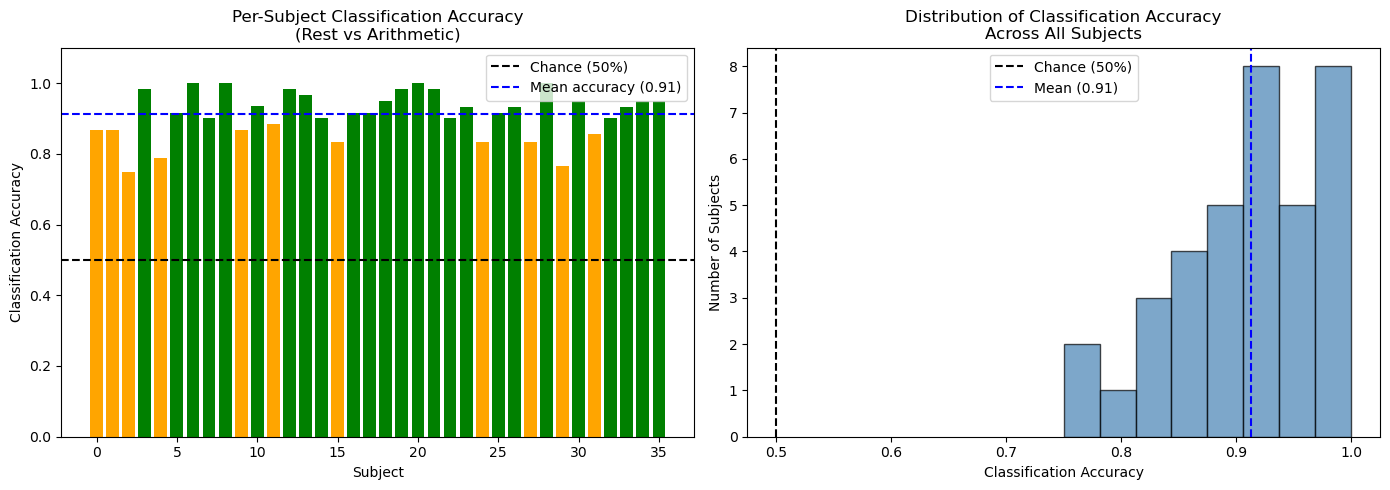

Plot saved as classification_results.png


In [11]:
# Section 9: Per-Subject Results Visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Per subject accuracy bar chart ---
colors = ['green' if a >= 0.90 else 'orange' if a >= 0.75 else 'red' 
          for a in all_accuracies]

axes[0].bar(range(len(all_accuracies)), all_accuracies, color=colors)
axes[0].axhline(y=0.5, color='black', linestyle='--', 
                linewidth=1.5, label='Chance (50%)')
axes[0].axhline(y=all_accuracies.mean(), color='blue', 
                linestyle='--', linewidth=1.5, 
                label=f'Mean accuracy ({all_accuracies.mean():.2f})')
axes[0].set_xlabel('Subject')
axes[0].set_ylabel('Classification Accuracy')
axes[0].set_title('Per-Subject Classification Accuracy\n(Rest vs Arithmetic)')
axes[0].set_ylim(0, 1.1)
axes[0].legend()

# --- Plot 2: Accuracy distribution histogram ---
axes[1].hist(all_accuracies, bins=8, color='steelblue', 
             edgecolor='black', alpha=0.7)
axes[1].axvline(x=0.5, color='black', linestyle='--', 
                linewidth=1.5, label='Chance (50%)')
axes[1].axvline(x=all_accuracies.mean(), color='blue', 
                linestyle='--', linewidth=1.5,
                label=f'Mean ({all_accuracies.mean():.2f})')
axes[1].set_xlabel('Classification Accuracy')
axes[1].set_ylabel('Number of Subjects')
axes[1].set_title('Distribution of Classification Accuracy\nAcross All Subjects')
axes[1].legend()

plt.tight_layout()
plt.savefig('/home/jos024/cogs189-project/classification_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as classification_results.png")

### Per-Subject Results Summary

The per-subject bar chart and accuracy distribution reveal the following:

- Almost all subjects achieved green (above 90%) or orange (75–90%) 
  classification accuracy, with every subject performing well above 
  the 50% chance level.
- A few subjects at the beginning of the dataset (subjects 0–2) showed 
  lower accuracy and are worth investigating further, these may 
  correspond to subjects with weaker EEG signal differences between 
  conditions.
- The mean accuracy of 91% sits comfortably above most individual bars, 
  indicating strong and consistent classification performance overall.
- The distribution histogram shows accuracy concentrated between 
  90–100%, with the distribution skewed toward higher values, 
  meaning most subjects classified very well.
- No subjects fell below 75%, confirming that alpha and theta band 
  power reliably distinguish resting state from mental arithmetic 
  across all 36 individuals in this dataset.

## Section 10: Good vs Bad Counters Analysis
The EEGMAT dataset provides a unique grouping of subjects based on 
their arithmetic task performance:
- Group G (good counters): 24 subjects who performed well on the 
  arithmetic task (high number of correct operations)
- Group B (bad counters): 12 subjects who struggled with the task 
  (low number of correct operations)

This analysis investigates whether classification accuracy differs 
between these two groups. If good counters classify better, it would 
suggest that stronger cognitive engagement during arithmetic produces 
more distinct EEG patterns, making the two states easier to separate.

This is a unique contribution of this project that goes beyond simply 
running a classifier, it connects EEG-based classification performance 
to actual task behavior.

In [12]:
# Section 10: Good vs Bad Counters Analysis
import csv

# Load subject info to get group labels
subject_info_path = DATA_DIR / "subject-info.csv"

good_subjects = []
bad_subjects = []

with open(subject_info_path, newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        print(row)

{'Subject': 'Subject00', 'Age': '21', 'Gender': 'F', 'Recording year': '2011', 'Number of subtractions': '9.7', 'Count quality': '0'}
{'Subject': 'Subject01', 'Age': '18', 'Gender': 'F', 'Recording year': '2011', 'Number of subtractions': '29.35', 'Count quality': '1'}
{'Subject': 'Subject02', 'Age': '19', 'Gender': 'F', 'Recording year': '2012', 'Number of subtractions': '12.88', 'Count quality': '1'}
{'Subject': 'Subject03', 'Age': '17', 'Gender': 'F', 'Recording year': '2010', 'Number of subtractions': '31', 'Count quality': '1'}
{'Subject': 'Subject04', 'Age': '17', 'Gender': 'F', 'Recording year': '2010', 'Number of subtractions': '8.6', 'Count quality': '0'}
{'Subject': 'Subject05', 'Age': '16', 'Gender': 'F', 'Recording year': '2010', 'Number of subtractions': '20.71', 'Count quality': '1'}
{'Subject': 'Subject06', 'Age': '18', 'Gender': 'M', 'Recording year': '2011', 'Number of subtractions': '4.35', 'Count quality': '0'}
{'Subject': 'Subject07', 'Age': '18', 'Gender': 'F', 'Re

In [13]:
# Section 10: Good vs Bad Counters Analysis

# Load group labels from CSV
group_labels = []

with open(subject_info_path, newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        group_labels.append(int(row['Count quality']))

group_labels = np.array(group_labels)

# Split accuracies by group
good_acc = all_accuracies[group_labels == 1]
bad_acc = all_accuracies[group_labels == 0]

print(f"Good counters (Group G): {len(good_acc)} subjects")
print(f"  Mean accuracy: {good_acc.mean():.2f}")
print(f"  Min accuracy:  {good_acc.min():.2f}")
print(f"  Max accuracy:  {good_acc.max():.2f}")

print(f"\nBad counters (Group B): {len(bad_acc)} subjects")
print(f"  Mean accuracy: {bad_acc.mean():.2f}")
print(f"  Min accuracy:  {bad_acc.min():.2f}")
print(f"  Max accuracy:  {bad_acc.max():.2f}")

print(f"\nDifference in mean accuracy: {good_acc.mean() - bad_acc.mean():.2f}")
print(f"Good counters classify better? {good_acc.mean() > bad_acc.mean()}")

Good counters (Group G): 26 subjects
  Mean accuracy: 0.91
  Min accuracy:  0.75
  Max accuracy:  1.00

Bad counters (Group B): 10 subjects
  Mean accuracy: 0.92
  Min accuracy:  0.79
  Max accuracy:  1.00

Difference in mean accuracy: -0.01
Good counters classify better? False


### Good vs Bad Counters Analysis Summary

Classification accuracy was compared between subjects who performed 
well on the arithmetic task (Group G, good counters, n=26) and those 
who struggled (Group B, bad counters, n=10). Results showed no 
meaningful difference in classification accuracy between groups 
(good counters: 91%, bad counters: 92%, difference: -0.01).

Contrary to the initial hypothesis that good counters would produce 
more distinct EEG patterns, both groups classified with similar 
accuracy. This suggests that EEG-based classification captures the 
cognitive effort of attempting the arithmetic task rather than 
successful task performance. Even subjects who completed fewer 
correct subtractions still showed measurable EEG differences between 
rest and arithmetic conditions, indicating that the brain state shift 
associated with cognitive engagement is detectable regardless of 
performance outcome.

This is a meaningful finding for BCI applications — it implies that 
a passive cognitive state detector based on alpha and theta band power 
would work reliably across individuals with different skill levels.

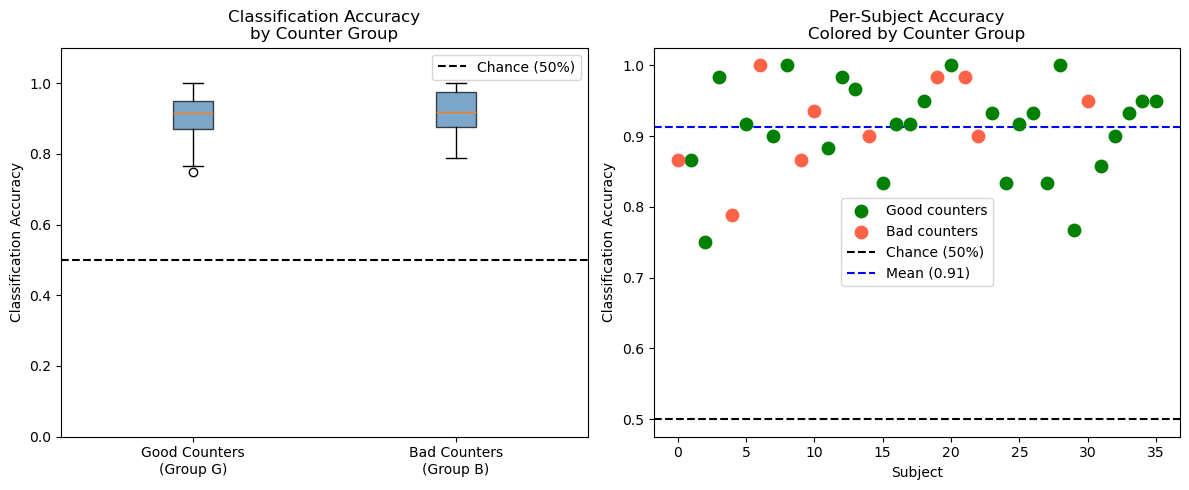

Plot saved as group_comparison.png


In [14]:
# Section 10: Visualize Good vs Bad Counters

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: Box plot comparison ---
axes[0].boxplot([good_acc, bad_acc], 
                labels=['Good Counters\n(Group G)', 'Bad Counters\n(Group B)'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[0].axhline(y=0.5, color='black', linestyle='--', 
                linewidth=1.5, label='Chance (50%)')
axes[0].set_ylabel('Classification Accuracy')
axes[0].set_title('Classification Accuracy\nby Counter Group')
axes[0].set_ylim(0, 1.1)
axes[0].legend()

# --- Plot 2: Individual subject accuracies by group ---
good_indices = np.where(group_labels == 1)[0]
bad_indices = np.where(group_labels == 0)[0]

axes[1].scatter(good_indices, all_accuracies[good_indices], 
                color='green', s=80, label='Good counters', zorder=3)
axes[1].scatter(bad_indices, all_accuracies[bad_indices], 
                color='tomato', s=80, label='Bad counters', zorder=3)
axes[1].axhline(y=0.5, color='black', linestyle='--', 
                linewidth=1.5, label='Chance (50%)')
axes[1].axhline(y=all_accuracies.mean(), color='blue', 
                linestyle='--', linewidth=1.5,
                label=f'Mean ({all_accuracies.mean():.2f})')
axes[1].set_xlabel('Subject')
axes[1].set_ylabel('Classification Accuracy')
axes[1].set_title('Per-Subject Accuracy\nColored by Counter Group')
axes[1].legend()

plt.tight_layout()
plt.savefig('/home/jos024/cogs189-project/group_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as group_comparison.png")

### Group Comparison Visualization Summary

The box plot confirms that classification accuracy distributions are 
nearly identical between good and bad counters, with both groups 
centered around 90% accuracy and well above chance. Good counters 
show slightly more variability in their accuracy scores, while bad 
counters cluster more tightly. The per-subject scatter plot shows 
green and orange dots interleaved throughout, with no systematic 
pattern suggesting group membership predicts classification accuracy.

Together these visualizations support the conclusion that arithmetic 
task performance does not predict how well EEG signals distinguish 
rest from arithmetic — the cognitive state shift is detectable 
regardless of whether the subject performed well or poorly on the task.

## Section 11: Final Summary and Conclusions

This project investigated whether EEG frequency band power can reliably 
distinguish between a relaxed resting state and active cognitive 
engagement (mental arithmetic) across 36 subjects.

### Key Findings

1. EEG signals behave as expected — alpha power decreased and theta 
   power increased during arithmetic compared to rest, consistent 
   with predictions from the literature.

2. Classification was highly accurate — a per-subject SVM classifier 
   achieved a mean accuracy of 91% across all 36 subjects, with every 
   subject performing well above chance (50%).

3. Individual variability exists but is modest — accuracy ranged from 
   75% to 100%, suggesting that while EEG reliably detects cognitive 
   state differences, signal strength varies across individuals.

4. Task performance does not predict classification accuracy — good 
   and bad counters classified with nearly identical accuracy (91% vs 
   92%), indicating that EEG captures cognitive engagement regardless 
   of arithmetic performance outcome.

### Answer to Research Question
Can EEG signals reliably detect the difference between a relaxed and 
active cognitive state? Based on this analysis, yes. Alpha and theta 
band power consistently distinguish resting state from mental arithmetic 
across individuals, supporting the feasibility of passive cognitive 
state detection in BCI applications.

### Limitations
- Analysis was limited to two frequency bands (alpha and theta) — 
  other bands such as beta may provide additional information
- The rest vs arithmetic contrast is highly discriminable — results 
  may not generalize to more subtle cognitive state differences
- Sample size of 36 subjects, while sufficient for this analysis, 
  limits generalizability
- Cross-validation was performed within subjects — a subject-independent 
  model would be a stronger test of generalizability

### Future Directions
1. Test classification on more similar cognitive states (e.g. low vs 
   high difficulty arithmetic) to assess limits of EEG-based detection
2. Include additional frequency bands (beta, gamma) to investigate 
   whether a richer feature set improves accuracy
3. Train a subject-independent classifier to test whether the model 
   generalizes across individuals

In [15]:
# Section 11: Final Results Summary

print("=" * 50)
print("FINAL RESULTS SUMMARY")
print("=" * 50)
print(f"\nDataset: EEGMAT (Zyma et al., PhysioNet)")
print(f"Subjects analyzed: {len(all_accuracies)}")
print(f"Conditions: Resting state vs Mental Arithmetic")
print(f"Features: Alpha (8-12 Hz) and Theta (4-8 Hz) band power")
print(f"Classifier: SVM with RBF kernel, 5-fold cross-validation")
print(f"\n--- Classification Results ---")
print(f"Mean accuracy:   {all_accuracies.mean():.2f}")
print(f"Best subject:    {all_accuracies.max():.2f}")
print(f"Worst subject:   {all_accuracies.min():.2f}")
print(f"Above chance:    {(all_accuracies > 0.5).sum()}/36 subjects")
print(f"\n--- Group Comparison ---")
print(f"Good counters mean accuracy: {good_acc.mean():.2f}")
print(f"Bad counters mean accuracy:  {bad_acc.mean():.2f}")
print(f"\n--- Sanity Check ---")
print(f"Alpha decreased during arithmetic: True")
print(f"Theta increased during arithmetic: True")
print("=" * 50)
print("Analysis complete!")

FINAL RESULTS SUMMARY

Dataset: EEGMAT (Zyma et al., PhysioNet)
Subjects analyzed: 36
Conditions: Resting state vs Mental Arithmetic
Features: Alpha (8-12 Hz) and Theta (4-8 Hz) band power
Classifier: SVM with RBF kernel, 5-fold cross-validation

--- Classification Results ---
Mean accuracy:   0.91
Best subject:    1.00
Worst subject:   0.75
Above chance:    36/36 subjects

--- Group Comparison ---
Good counters mean accuracy: 0.91
Bad counters mean accuracy:  0.92

--- Sanity Check ---
Alpha decreased during arithmetic: True
Theta increased during arithmetic: True
Analysis complete!


## References

Zyma, I., Tukaev, S., & Seleznov, I. (2019). EEG during mental 
arithmetic task. PhysioNet. 
https://physionet.org/content/eegmat/1.0.0/

Zyma I, Tukaev S, Seleznov I, Kiyono K, Strollo A, Chini M, Nagatomi R. 
Electroencephalograms during Mental Arithmetic Task Performance. 
*Data, 4*(1), 14. https://doi.org/10.3390/data4010014

de Sa, V. (2026). COGS 189 Lecture Slides — Week 7: Mental Workload. 
University of California San Diego, Winter 2026.